# reliance sales project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("Reliance.csv")
print(df.columns)
print(df.index)
df['Date'] = pd.to_datetime(df['Date'])

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')
RangeIndex(start=0, stop=1233, step=1)


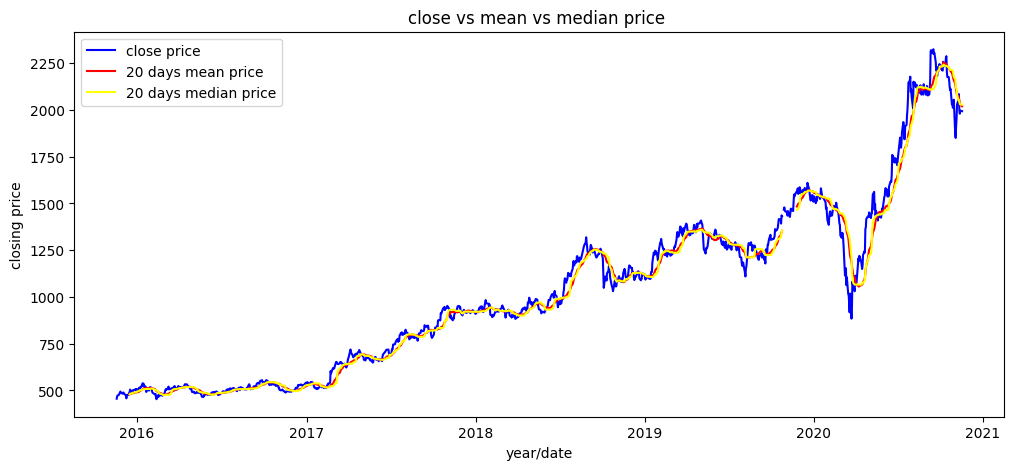

In [3]:
# Price  Trend And Moving Average (Sirf Close Price Par)

df['mean_20'] = df['Close'].rolling(window=20).mean()
df['median_20'] = df['Close'].rolling(window=20).median()

# df[['mean_20','median_20']]

plt.figure(figsize=(12,5))
plt.plot(df['Date'],df['Close'], label='close price' , color='blue')
plt.plot(df['Date'],df['mean_20'], label='20 days mean price' , color='red')
plt.plot(df['Date'],df['median_20'], label='20 days median price' , color='yellow')
plt.xlabel('year/date')
plt.ylabel('closing price')
plt.title('close vs mean vs median price ')
plt.legend()
plt.show()

In [4]:
# Task 2: Market Ka Sabse Bada Darr (High Volatility Days)
# Humein dekhna hai ki wo kaun se din the jab market me sabse zyada halchal hui thi. Iske liye hum har din ke High aur Low ka farq nikalte hain.

df['volatility'] = df['High'] - df['Low']

high_volatility = df[df['volatility'] == df['volatility'].max()]

print("---------------- high volatility day ---------------------- ")
print(type(high_volatility))
high_volatility

---------------- high volatility day ---------------------- 
<class 'pandas.DataFrame'>


,Date,Open,High,Low,Close,Adj Close,Volume,mean_20,median_20,volatility
1063,2020-03-13,998.0,1140.0,942.400024,1105.300049,1101.165405,33509107.0,1344.112506,1364.549988,197.599976


In [5]:
# task 3: Volume Ka Khel (Bheed Kab Aayi?)
# Humein dhoondna hai ki 1029  dino me wo kaunse top 5 din the jab Reliance me sabse zyada trading (Volume) hui.

volume = df.sort_values(by='Volume',ascending=False).head()
volume

,Date,Open,High,Low,Close,Adj Close,Volume,mean_20,median_20,volatility
1087,2020-04-22,1320.000000,1384.900024,1300.000000,1363.599976,1358.499023,65230035.0,1127.777490,1131.799988,84.900024
1186,2020-09-10,2183.100098,2344.949951,2175.350098,2314.000000,2314.000000,64750460.0,2116.332532,2108.850098,169.599853
1145,2020-07-15,1937.949951,1978.800049,1798.000000,1844.000000,1844.000000,64457578.0,1782.720007,1759.875000,180.800049
1089,2020-04-24,1350.150024,1494.949951,1347.199951,1417.000000,1411.699341,61711199.0,1172.072491,1178.600036,147.750000
312,2017-02-22,546.500000,605.825012,546.000000,603.750000,590.290466,58207852.0,526.621254,522.075012,59.825012


In [6]:
# Task 4: Monthly Analysis (Data Ka Grouping)
# Sirf daily nahi, humein dekhna hai ki saal ke kis mahine me Reliance sabse zyada high price par hota hai aur kis mahine me sasta hota hai.

# df['Month'] = df['Date'].dt.strftime('%B')

# monthly_avg = df.groupby('Month')['Close'].mean() # .sort_values(ascending=False)



<class 'pandas.Series'>
Month_Num
1      950.641517
2      917.501548
3      884.391751
4      959.767073
5      961.487712
6     1013.432382
7     1130.067890
8     1167.278338
9     1224.525002
10    1234.106062
11    1064.152450
12     912.800475
Name: Close, dtype: float64
Month Number (1=Jan, 12=Dec) ke hisab se sorted:
        month        Close
1     january   950.641517
2    february   917.501548
3       march   884.391751
4       april   959.767073
5         may   961.487712
6        june  1013.432382
7        july  1130.067890
8      august  1167.278338
9   spetember  1224.525002
10   octomber  1234.106062
11   november  1064.152450
12   december   912.800475


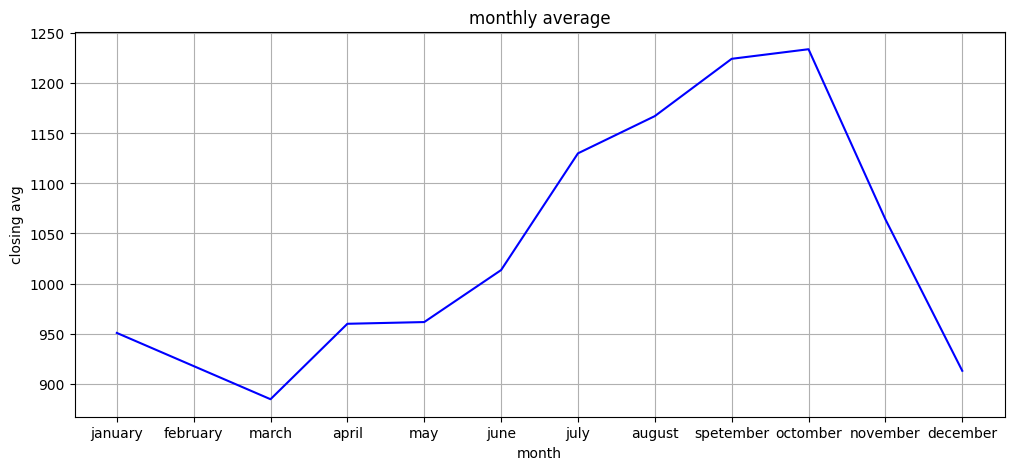

In [7]:
# 1. Date se month ka number (01, 02, 03) nikal kar naya column banao
df['Month_Num'] = df['Date'].dt.month

# 2. Month number ke hisab se group karke mean nikalo
monthly_avg = df.groupby('Month_Num')['Close'].mean()
print(type(monthly_avg))
print(monthly_avg)

month = pd.DataFrame({"month" : ['january' , 'february' , 'march','april','may','june','july','august','spetember','octomber','november','december']},index=[1,2,3,4,5,6,7,8,9,10,11,12])

x = pd.concat((month,monthly_avg),axis=1)
print("Month Number (1=Jan, 12=Dec) ke hisab se sorted:")
print(x)



plt.figure(figsize=(12,5))
plt.plot(x['month'],x['Close'] ,color='blue')
plt.title("monthly average")
plt.xlabel('month')
plt.ylabel("closing avg")
plt.grid(True)

plt.show()

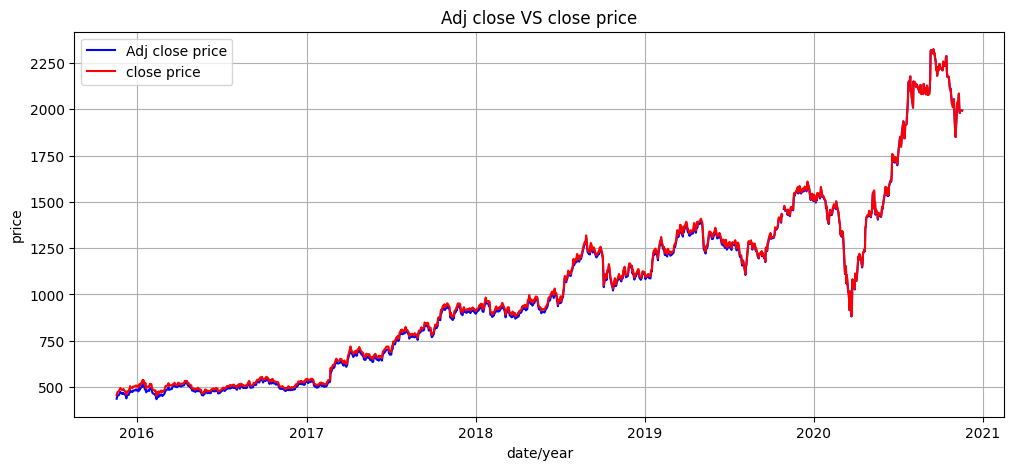

In [8]:
#  adj close VS close price graph

plt.figure(figsize=(12,5))
plt.plot(df['Date'],df['Adj Close'],label='Adj close price',color='blue')
plt.plot(df['Date'],df['Close'],label='close price',color='red')
plt.xlabel("date/year")
plt.ylabel("price")
plt.title("Adj close VS close price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#  yearly analysis

df['year'] = df['Date'].dt.year

# df['month_name'] = df['Date'].dt.strftime('%B')

year_avg = df.groupby(by=['year', 'Month_Num'])['Close'].mean().reset_index()


def month(x):
    m = { 1:'january' , 2:'february' , 3:'march' , 4:'april' , 5:'may' , 6: 'june' , 7:'july' , 8:'august',
                    9:'september' , 10:'octomber' , 11:'november' , 12:'december' }
    
    return m.get(x , "invalid number")

year_avg['month name'] = pd.DataFrame(year_avg['Month_Num'].apply(month))
year_avg

# year_avg = df.groupby(by=['year', 'month_name'])['Close'].mean().reset_index()
# year_avg




,year,Month_Num,Close,month name
0,2015,11,478.115623,november
1,2015,12,489.512502,december
2,2016,1,512.619998,january
3,2016,2,478.789286,february
4,2016,3,511.636247,march
...,...,...,...,...
56,2020,7,1939.930436,july
57,2020,8,2110.792899,august
58,2020,9,2214.381836,september
59,2020,10,2161.842855,octomber


    year  Month_Num        Close month name
50  2020          1  1517.145656    january
51  2020          2  1440.836850   february
52  2020          3  1101.447620      march
53  2020          4  1270.937771      april
54  2020          5  1459.850534        may
55  2020          6  1632.231823       june
56  2020          7  1939.930436       july
57  2020          8  2110.792899     august
58  2020          9  2214.381836  september
59  2020         10  2161.842855   octomber
60  2020         11  1975.209084   november


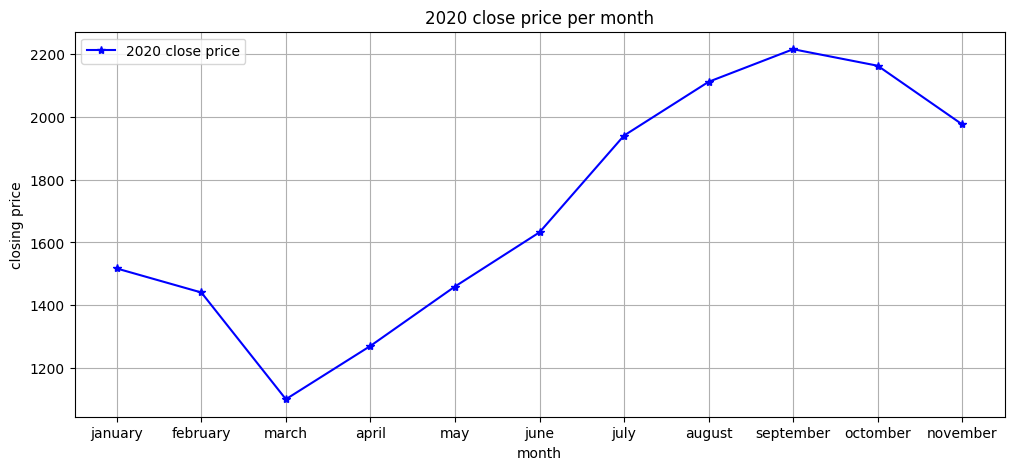

In [ ]:
# graph of closing price per year of month
close_2020 = year_avg[year_avg['year'] == 2020].sort_values(by='Month_Num')
print(close_2020)

plt.figure(figsize=(12,5))
plt.plot(close_2020['month name'],close_2020['Close'],label='2020 close price',color='blue',marker="*")
plt.title('2020 close price per month')
plt.xlabel('month')
plt.ylabel('closing price')
plt.legend()
plt.grid(True) 
plt.show() 

In [11]:
print("highest colsing price of the year of the month ")
highest_close_price_of_year = year_avg[year_avg['Close'] == year_avg['Close'].max()]
highest_close_price_of_year  
  

highest colsing price of the year of the month 


,year,Month_Num,Close,month name
58,2020,9,2214.381836,september


In [12]:
print("lowest colsing price of the year of the month ")
lowest_close_price_of_year = year_avg[year_avg['Close'] == year_avg['Close'].min()]  
lowest_close_price_of_year        

lowest colsing price of the year of the month 


,year,Month_Num,Close,month name
0,2015,11,478.115623,november


In [13]:
 #  RSI - Relative strength indicator 
#          speedometer of market 
#          RSI > 70 - overbought
#          RSI < 30 - oversell

mix = df['Close'].diff()

gain = mix.where(mix>0 , 0)
loss = - (mix.where(mix<0 , 0))

x = pd.concat((df['Close'],gain.rename('gain'),loss.rename('loss')),axis=1)

avg_gain = gain.rolling(window=14).mean().dropna()
avg_loss = loss.rolling(window=14).mean().dropna()

rs = avg_gain / avg_loss

rsi = 100 - (100 / (100+rs))

df['RSI'] = rsi



In [ ]:
#  MACD CALCULATION

# .ewm() (Exponential Weighted Moving)

# EMA (Exponential Moving Average)

df['EMA_12'] = df['Close'].ewm(span=12 , adjust=False).mean()
df['EMA_28'] = df['Close'].ewm(span=28 , adjust=False).mean()

df['MACD_line'] = df['EMA_12'] - df['EMA_28'] 

df['signal_line'] = df['MACD_line'].ewm(span=9 , adjust=False).mean()

df['MACD_histogram'] = df['MACD_line'] - df['signal_line']  

df[['EMA_12', 'EMA_28' , 'MACD_line' , 'signal_line' , 'MACD_histogram']]  

,EMA_12,EMA_28,MACD_line,signal_line,MACD_histogram
0,456.000000,456.000000,0.000000,0.000000,0.000000
1,457.750000,456.784483,0.965517,0.193103,0.772414
2,460.161537,457.932104,2.229433,0.600369,1.629063
3,462.732839,459.238510,3.494328,1.179161,2.315167
4,465.981634,460.935855,5.045779,1.952485,3.093294
...,...,...,...,...,...
1228,2024.046265,2077.795925,-53.749660,-59.702557,5.952896
1229,2019.916063,2072.237582,-52.321519,-58.226349,5.904830
1230,2013.775130,2065.876370,-52.101240,-57.001327,4.900088
1231,2011.102037,2061.084898,-49.982861,-55.597634,5.614773


In [ ]:
fig_rsi = go.Figure()

fig_rsi.add_trace(go.Scatter(
    x= df['Date'],
    y= df['RSI'],
    mode= 'lines',
    name= 'relience close',
    line=dict(color='blue', width=2)
     ))

fig_rsi.update_layout(
    title='Reliance Interactive Price Chart',
    xaxis_title='Date/year',
    yaxis_title='Price (₹)',
    hovermode='x unified', # Isse ek hi date ka saara data ek sath mouse par dikhega
    template='plotly_dark' # Aapka favorite Dark Mode theme!
)

# 4. JADU: Graph ko screen par show karna
fig_rsi.show()

In [ ]:


# Step 1: Ek single khali canvas banaya (No subplots!)
fig = go.Figure()

colors = ['green' if val >= 0 else 'red' for val in df['MACD_histogram']]

# Step 2: Pehli line add ki (MACD Line)
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MACD_line'],
    mode='lines',
    name='MACD Line (Fast)',
    line=dict(color='green', width=2)
))

# Step 3: Dusri line add ki (Signal Line) - Yeh automatic usi graph me plot hogi!
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['signal_line'],
    mode='lines',
    name='Signal Line (Slow)',
    line=dict(color='red', width=2, dash='dot') # Isko dotted line bana diya
))

# Step 4: Teesra element add kiya (Histogram) - Bars ke roop me
fig.add_trace(go.Bar(
    x=df['Date'],
    y=df['MACD_histogram'],
    name='Histogram',
    marker=dict(color=colors, opacity=1.0) 
))

# Step 5: Layout set kiya
fig.update_layout(
    title='MACD Full Indicator in a Single Graph',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    template='plotly_white'
)  

fig.show() 